<a href="https://colab.research.google.com/github/aljubic1/bioinformatika_projekt_alj/blob/main/notebooks/04_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. Evaluation

## Cilj

Cilj ovog notebooka je detaljnije evaluirati rezultate modela za klasifikaciju antimikrobnih peptida. Analizirat će se matrice zabune, klasifikacijski izvještaji i važnost značajki kako bi se bolje razumjelo ponašanje modela.

In [3]:
# Uvoz pandas biblioteke.
import pandas as pd

# Uvoz biblioteke za crtanje grafova.
import matplotlib.pyplot as plt

# Uvoz funkcija za podjelu podataka.
from sklearn.model_selection import train_test_split

# Uvoz funkcije za skaliranje.
from sklearn.preprocessing import StandardScaler

# Uvoz modela.
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Uvoz evaluacijskih metrika.
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
# Putanja do skupa značajki.
features_path = "features.csv"

# Učitavanje skupa značajki.
features_df = pd.read_csv(features_path)

# Prikaz prvih pet redaka.
features_df.head()

,ID,SEQUENCE,length,net_charge,hydrophobicity,label,AAC_A,AAC_C,AAC_D,AAC_E,...,AAC_M,AAC_N,AAC_P,AAC_Q,AAC_R,AAC_S,AAC_T,AAC_V,AAC_W,AAC_Y
0,1390,CFQWQRNARKVR,12,4,-1.458333,1,0.083333,0.083333,0.000000,0.000000,...,0.0,0.083333,0.0,0.166667,0.250000,0.000000,0.000000,0.083333,0.083333,0.000000
1,Seq8055_sampling_method=Wang-et-al_AMP=0_rep2,TEETKVIDSRLVSDGYQ,17,-2,-0.817647,0,0.000000,0.000000,0.117647,0.117647,...,0.0,0.000000,0.0,0.058824,0.058824,0.117647,0.117647,0.117647,0.000000,0.058824
2,1661,WLNALLHHGLNCAKGVL,17,3,0.605882,1,0.117647,0.058824,0.000000,0.000000,...,0.0,0.117647,0.0,0.000000,0.000000,0.000000,0.000000,0.058824,0.058824,0.000000
3,1552,RLWRIVVIRVAR,12,4,0.691667,1,0.083333,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.333333,0.000000,0.000000,0.250000,0.083333,0.000000
4,1585,ILGTILGLLKSL,12,1,1.816667,1,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0.000000


Priprema podataka i ponovno treniranje modela
## Priprema podataka za evaluaciju

Kako bi evaluacija bila usporediva s prethodnim notebookom, koristi se ista podjela podataka na trening i testni skup te isti parametri modela.

In [5]:
# Odvajanje ulaznih značajki od ciljne varijable.
X = features_df.drop(columns=["ID", "SEQUENCE", "label"])

# Ciljna varijabla.
y = features_df["label"]

# Podjela na trening i testni skup.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Skaliranje značajki za SVM.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Treniranje Random Forest modela.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predikcije Random Forest modela.
rf_predictions = rf_model.predict(X_test)

In [7]:
#za SVM
# Treniranje SVM modela.
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Predikcije SVM modela.
svm_predictions = svm_model.predict(X_test_scaled)

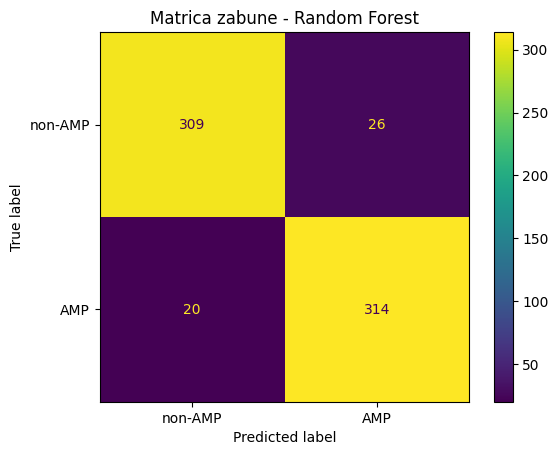

In [8]:
#confusion matrix.
#Random Forest confusion matrix
# Matrica zabune za Random Forest model.
rf_cm = confusion_matrix(y_test, rf_predictions)

# Prikaz matrice zabune.
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["non-AMP", "AMP"]
).plot()

plt.title("Matrica zabune - Random Forest")
plt.show()

### Tumačenje matrice zabune – Random Forest

Matrica zabune prikazuje broj ispravno i pogrešno klasificiranih uzoraka za Random Forest model.

- **309** non-AMP peptida ispravno je klasificirano kao non-AMP.
- **314** AMP peptida ispravno je klasificirano kao AMP.
- **26** non-AMP peptida pogrešno je klasificirano kao AMP.
- **20** AMP peptida pogrešno je klasificirano kao non-AMP.

Rezultati pokazuju da je Random Forest model ostvario vrlo visoku točnost klasifikacije te napravio mali broj pogrešnih predviđanja.

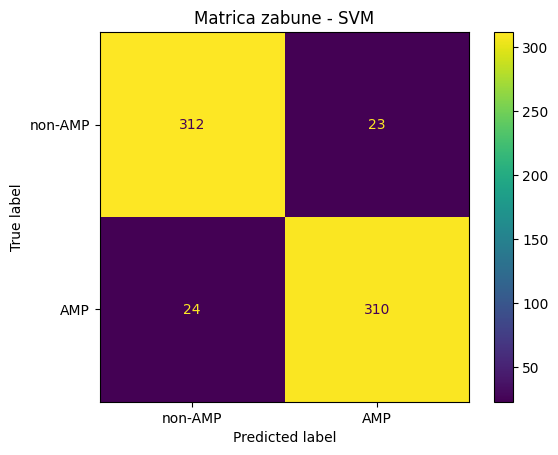

In [9]:
#SVM confusion matrix
# Matrica zabune za SVM model.
svm_cm = confusion_matrix(y_test, svm_predictions)

# Prikaz matrice zabune.
ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=["non-AMP", "AMP"]
).plot()

plt.title("Matrica zabune - SVM")
plt.show()

### Tumačenje matrice zabune – SVM

Matrica zabune prikazuje rezultate klasifikacije SVM modela.

- **312** non-AMP peptida ispravno je klasificirano kao non-AMP.
- **310** AMP peptida ispravno je klasificirano kao AMP.
- **23** non-AMP peptida pogrešno je klasificirano kao AMP.
- **24** AMP peptida pogrešno je klasificirano kao non-AMP.

SVM model također je ostvario vrlo dobre rezultate, uz mali broj pogrešnih klasifikacija. U odnosu na Random Forest, model je imao nešto manje pogrešaka kod non-AMP peptida, ali nešto više kod AMP peptida.

## Classification Report

Uz matricu zabune prikazuje se i klasifikacijski izvještaj (Classification Report), koji sadrži vrijednosti preciznosti (Precision), odziva (Recall), F1-mjere i broja uzoraka (Support) za svaku klasu.

In [10]:
# Klasifikacijski izvještaj za Random Forest.
print("Random Forest")
print("=" * 50)

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["non-AMP", "AMP"]
    )
)

Random Forest
              precision    recall  f1-score   support

     non-AMP       0.94      0.92      0.93       335
         AMP       0.92      0.94      0.93       334

    accuracy                           0.93       669
   macro avg       0.93      0.93      0.93       669
weighted avg       0.93      0.93      0.93       669



In [11]:
# Klasifikacijski izvještaj za SVM.
print("Support Vector Machine")
print("=" * 50)

print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=["non-AMP", "AMP"]
    )
)

Support Vector Machine
              precision    recall  f1-score   support

     non-AMP       0.93      0.93      0.93       335
         AMP       0.93      0.93      0.93       334

    accuracy                           0.93       669
   macro avg       0.93      0.93      0.93       669
weighted avg       0.93      0.93      0.93       669



### Tumačenje Classification Report rezultata

Klasifikacijski izvještaj prikazuje preciznost (Precision), odziv (Recall), F1-mjeru i broj uzoraka (Support) za svaku klasu.

Random Forest model ostvario je vrlo dobre rezultate za obje klase. Za klasu **non-AMP** postignuta je preciznost od **0,94**, dok je za klasu **AMP** ostvaren odziv od **0,94**, što pokazuje da model vrlo uspješno prepoznaje antimikrobne peptide.

SVM model također je ostvario vrlo dobre rezultate, pri čemu su vrijednosti preciznosti, odziva i F1-mjere približno jednake za obje klase (oko **0,93**). To ukazuje na uravnotežene performanse modela bez izraženog favoriziranja pojedine klase.

Oba modela pokazala su visoku uspješnost klasifikacije, dok je Random Forest ostvario neznatno bolje ukupne rezultate, što potvrđuju i prethodno prikazane metrike te matrice zabune.

🌳 Sada radimo Feature Importance

Ovo je jedan od najvažnijih dijelova projekta jer pokazuje koje su bioinformatičke značajke bile najvažnije za klasifikaciju.

## Važnost značajki (Feature Importance)

Random Forest omogućuje procjenu važnosti pojedinih značajki korištenih tijekom klasifikacije. Analiza važnosti značajki pomaže razumjeti koja biološka svojstva najviše doprinose razlikovanju antimikrobnih i neantimikrobnih peptida.

In [12]:
# Dohvaćanje važnosti značajki.
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sortiranje prema važnosti.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Prikaz prvih 10 značajki.
feature_importance.head(10)

,Feature,Importance
1,net_charge,0.160260
6,AAC_E,0.096955
11,AAC_K,0.093487
5,AAC_D,0.089152
13,AAC_M,0.054361
2,hydrophobicity,0.042182
19,AAC_T,0.041506
4,AAC_C,0.041363
17,AAC_R,0.037102
0,length,0.036416


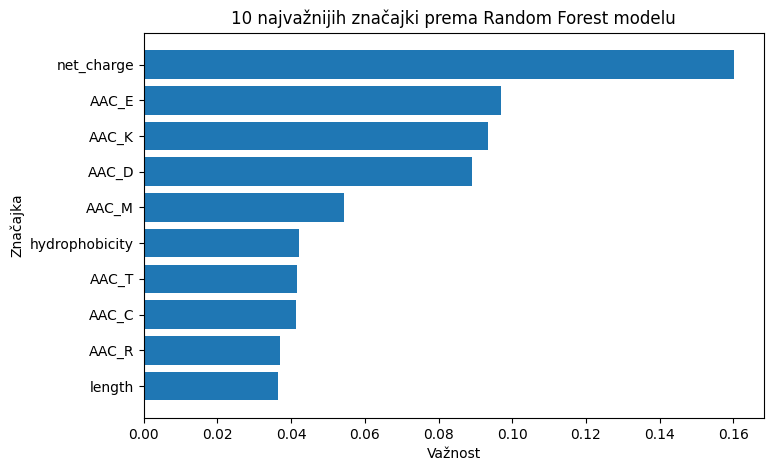

In [13]:
# Prikaz 10 najvažnijih značajki.
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Važnost")
plt.ylabel("Značajka")
plt.title("10 najvažnijih značajki prema Random Forest modelu")

plt.show()

Rezultati su i biološki vrlo smisleni:

🥇 net_charge je najvažnija značajka (0.160260)
🥈 Slijede udjeli aminokiselina E, K i D
🥉 Nakon toga dolaze hidrofobnost i duljina

To se odlično slaže s biologijom antimikrobnih peptida.
### Tumačenje važnosti značajki

Random Forest model omogućuje procjenu relativne važnosti pojedinih značajki korištenih tijekom klasifikacije.

Rezultati pokazuju da je **neto naboj (net_charge)** najvažnija značajka za razlikovanje antimikrobnih i neantimikrobnih peptida. To je u skladu s biološkim svojstvima antimikrobnih peptida, koji su najčešće pozitivno nabijeni i zbog toga učinkovito ostvaruju interakciju s negativno nabijenim membranama mikroorganizama.

Među najvažnijim značajkama nalaze se i aminokiselinski sastav (AAC), posebno udjeli aminokiselina **E**, **K**, **D** i **M**, kao i prosječna hidrofobnost sekvence. Duljina peptida također doprinosi klasifikaciji, ali u manjoj mjeri u odnosu na neto naboj i sastav aminokiselina.

Dobiveni rezultati potvrđuju da odabrane bioinformatičke značajke imaju biološko značenje te omogućuju uspješnu klasifikaciju antimikrobnih peptida.

# Zaključak

U ovom notebooku provedena je detaljna evaluacija modela za klasifikaciju antimikrobnih peptida. Analizirane su matrice zabune, klasifikacijski izvještaji i važnost značajki dobivena Random Forest modelom.

Oba modela ostvarila su vrlo dobre rezultate klasifikacije, pri čemu je Random Forest pokazao nešto bolje ukupne performanse u odnosu na SVM. Analiza važnosti značajki pokazala je da je neto naboj najvažnija bioinformatička značajka za razlikovanje antimikrobnih i neantimikrobnih peptida, što je u skladu s poznatim biološkim svojstvima antimikrobnih peptida.

Dobiveni rezultati potvrđuju da se odabrane bioinformatičke značajke mogu uspješno koristiti za klasifikaciju peptida primjenom metoda strojnog učenja.